In [1]:
from forestkernel import ForestKernel
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from dataset import dataprep

from sklearn.decomposition import TruncatedSVD, PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from scipy.sparse.linalg import eigsh



from time import time

/Users/aumona/Projects/RF-GAP-Python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data = pd.read_csv('/Users/aumona/Projects/RF-GAP-Python/data/organcmnist_train.csv')
data = pd.read_csv('/Users/aumona/Projects/RF-GAP-Python/data/sign_mnist_cropped.csv')
# data = pd.read_csv('/Users/aumona/Projects/RF-GAP-Python/data/gtzan_3_sec.csv')
# data = pd.read_csv('/Users/aumona/Projects/RF-GAP-Python/data/treeData.csv')

x, y = dataprep(data, scale='normalize')
# x, y = dataprep(data, scale='standardize')

# Make sure y is a NumPy array for indexing
y = np.asarray(y)

seed = 42

# ---------------------------------------------------------
# Train / test split
# ---------------------------------------------------------
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

# ---------------------------------------------------------
# Fit kernel only on training data
# ---------------------------------------------------------
# fk = ForestKernel(kernel_method='kerf', model_type='rf', random_state=seed)
fk = ForestKernel(kernel_method='kerf', model_type='rf', random_state=seed)

fk.fit(x_train, y_train)

# Train leaf representation (reference side)
leaf_emb_train = fk.get_reference_map()

# Training kernel matrix
K_train = leaf_emb_train @ leaf_emb_train.T

# Test leaf representation (query side / extension)
leaf_emb_test = fk.get_query_map(x_test)

# Test kernel matrix
K_test = leaf_emb_test @ leaf_emb_train.T

print("Train leaf embedding shape:", leaf_emb_train.shape)
print("Train kernel matrix shape:", K_train.shape)

print("Test leaf embedding shape:", leaf_emb_test.shape)
print("Test kernel matrix shape:", K_test.shape)

print("Train leaf embedding type:", type(leaf_emb_train))
print("Train kernel matrix type:", type(K_train))

print("Test leaf embedding type:", type(leaf_emb_test))
print("Test kernel matrix type:", type(K_test))


Train leaf embedding shape: (11585, 143550)
Train kernel matrix shape: (11585, 11585)
Test leaf embedding shape: (2897, 143550)
Test kernel matrix shape: (2897, 11585)
Train leaf embedding type: <class 'scipy.sparse._csr.csr_matrix'>
Train kernel matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Test leaf embedding type: <class 'scipy.sparse._csr.csr_matrix'>
Test kernel matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [ ]:

# ---------------------------------------------------------
# 2D embeddings fit on train only, then transform test
# ---------------------------------------------------------

# Raw PCA
raw_pca = PCA(n_components=2, random_state=seed)
x_pca_raw_train = raw_pca.fit_transform(x_train)
x_pca_raw_test = raw_pca.transform(x_test)

# Raw UMAP via SVD(30) first
raw_svd30 = TruncatedSVD(n_components=30, random_state=seed)
x_raw_svd30_train = raw_svd30.fit_transform(x_train)
x_raw_svd30_test = raw_svd30.transform(x_test)

raw_umap = UMAP(n_components=2, random_state=seed)
x_umap_raw_train = raw_umap.fit_transform(x_raw_svd30_train, y=y_train)
x_umap_raw_test = raw_umap.transform(x_raw_svd30_test)

# Leaf TruncatedSVD
leaf_svd2 = TruncatedSVD(n_components=2, random_state=seed)
x_svd_leaf_train = leaf_svd2.fit_transform(leaf_emb_train)
x_svd_leaf_test = leaf_svd2.transform(leaf_emb_test)

# Leaf PCA
leaf_pca = PCA(n_components=2, random_state=seed)
x_pca_leaf_train = leaf_pca.fit_transform(
    leaf_emb_train.toarray() if hasattr(leaf_emb_train, "toarray") else leaf_emb_train
)
x_pca_leaf_test = leaf_pca.transform(
    leaf_emb_test.toarray() if hasattr(leaf_emb_test, "toarray") else leaf_emb_test
)

# Leaf UMAP via SVD(30) first
leaf_svd30 = TruncatedSVD(n_components=30, random_state=seed)
x_leaf_svd30_train = leaf_svd30.fit_transform(leaf_emb_train)
x_leaf_svd30_test = leaf_svd30.transform(leaf_emb_test)

leaf_umap = UMAP(n_components=2, random_state=seed)
x_umap_leaf_train = leaf_umap.fit_transform(x_leaf_svd30_train, y=y_train)
x_umap_leaf_test = leaf_umap.transform(x_leaf_svd30_test)

# ---------------------------------------------------------
# Kernel route: use eigendecomposition so it matches leaf SVD
# ---------------------------------------------------------

def kernel_embedding_from_eig(K_train, K_test, n_components, seed=None):
    """
    Compute the train/test kernel spectral embedding corresponding to
    the leaf-SVD embedding when K = Q Q^T.

    Train embedding:
        X_train = V sqrt(Lambda)

    Test embedding (Nyström extension):
        X_test = K_test V Lambda^{-1/2}

    where K_train = V Lambda V^T.
    """
    # eigsh returns eigenvalues in ascending order
    evals, evecs = eigsh(K_train, k=n_components, which="LM", rng=np.random.default_rng(seed))

    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    # Numerical safety
    evals = np.maximum(evals, 1e-12)

    x_train = evecs * np.sqrt(evals)[None, :]
    x_test = (K_test @ evecs) / np.sqrt(evals)[None, :]

    return x_train, x_test, evals, evecs

# Kernel embedding equivalent to leaf TruncatedSVD(2)
x_svd_kernel_train, x_svd_kernel_test, evals2, evecs2 = kernel_embedding_from_eig(
    K_train, K_test, n_components=2, seed=seed
)

# Kernel UMAP via kernel spectral embedding in 30d first
x_kernel_svd30_train, x_kernel_svd30_test, evals30, evecs30 = kernel_embedding_from_eig(
    K_train, K_test, n_components=30, seed=seed
)

kernel_umap = UMAP(n_components=2, random_state=seed)
x_umap_kernel_train = kernel_umap.fit_transform(x_kernel_svd30_train, y=y_train)
x_umap_kernel_test = kernel_umap.transform(x_kernel_svd30_test)

/Users/aumona/Projects/RF-GAP-Python/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:

# ---------------------------------------------------------
# 5-NN evaluation
# ---------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5)

def eval_knn(xtr, xte, ytr, yte):
    knn.fit(xtr, ytr)
    return knn.score(xte, yte)

score_raw_pca = eval_knn(x_pca_raw_train, x_pca_raw_test, y_train, y_test)
score_raw_umap = eval_knn(x_umap_raw_train, x_umap_raw_test, y_train, y_test)
score_leaf_svd = eval_knn(x_svd_leaf_train, x_svd_leaf_test, y_train, y_test)
score_leaf_pca = eval_knn(x_pca_leaf_train, x_pca_leaf_test, y_train, y_test)
score_leaf_umap = eval_knn(x_umap_leaf_train, x_umap_leaf_test, y_train, y_test)
score_kernel_svd = eval_knn(x_svd_kernel_train, x_svd_kernel_test, y_train, y_test)
score_kernel_umap = eval_knn(x_umap_kernel_train, x_umap_kernel_test, y_train, y_test)

print("5-NN test accuracy on raw PCA(2):", score_raw_pca)
print("5-NN test accuracy on raw UMAP(2):", score_raw_umap)
print("5-NN test accuracy on leaf TruncatedSVD(2):", score_leaf_svd)
print("5-NN test accuracy on leaf PCA(2):", score_leaf_pca)
print("5-NN test accuracy on leaf UMAP(2):", score_leaf_umap)
print("5-NN test accuracy on kernel TruncatedSVD(2):", score_kernel_svd)
print("5-NN test accuracy on kernel UMAP(2):", score_kernel_umap)


5-NN test accuracy on raw PCA(2): 0.4004142216085606
5-NN test accuracy on raw UMAP(2): 0.9627200552295478
5-NN test accuracy on leaf TruncatedSVD(2): 0.8709009319986193
5-NN test accuracy on leaf PCA(2): 0.9250949257852952
5-NN test accuracy on leaf UMAP(2): 0.9872281670693821
5-NN test accuracy on kernel TruncatedSVD(2): 0.619261304798067
5-NN test accuracy on kernel UMAP(2): 0.9948222298929927


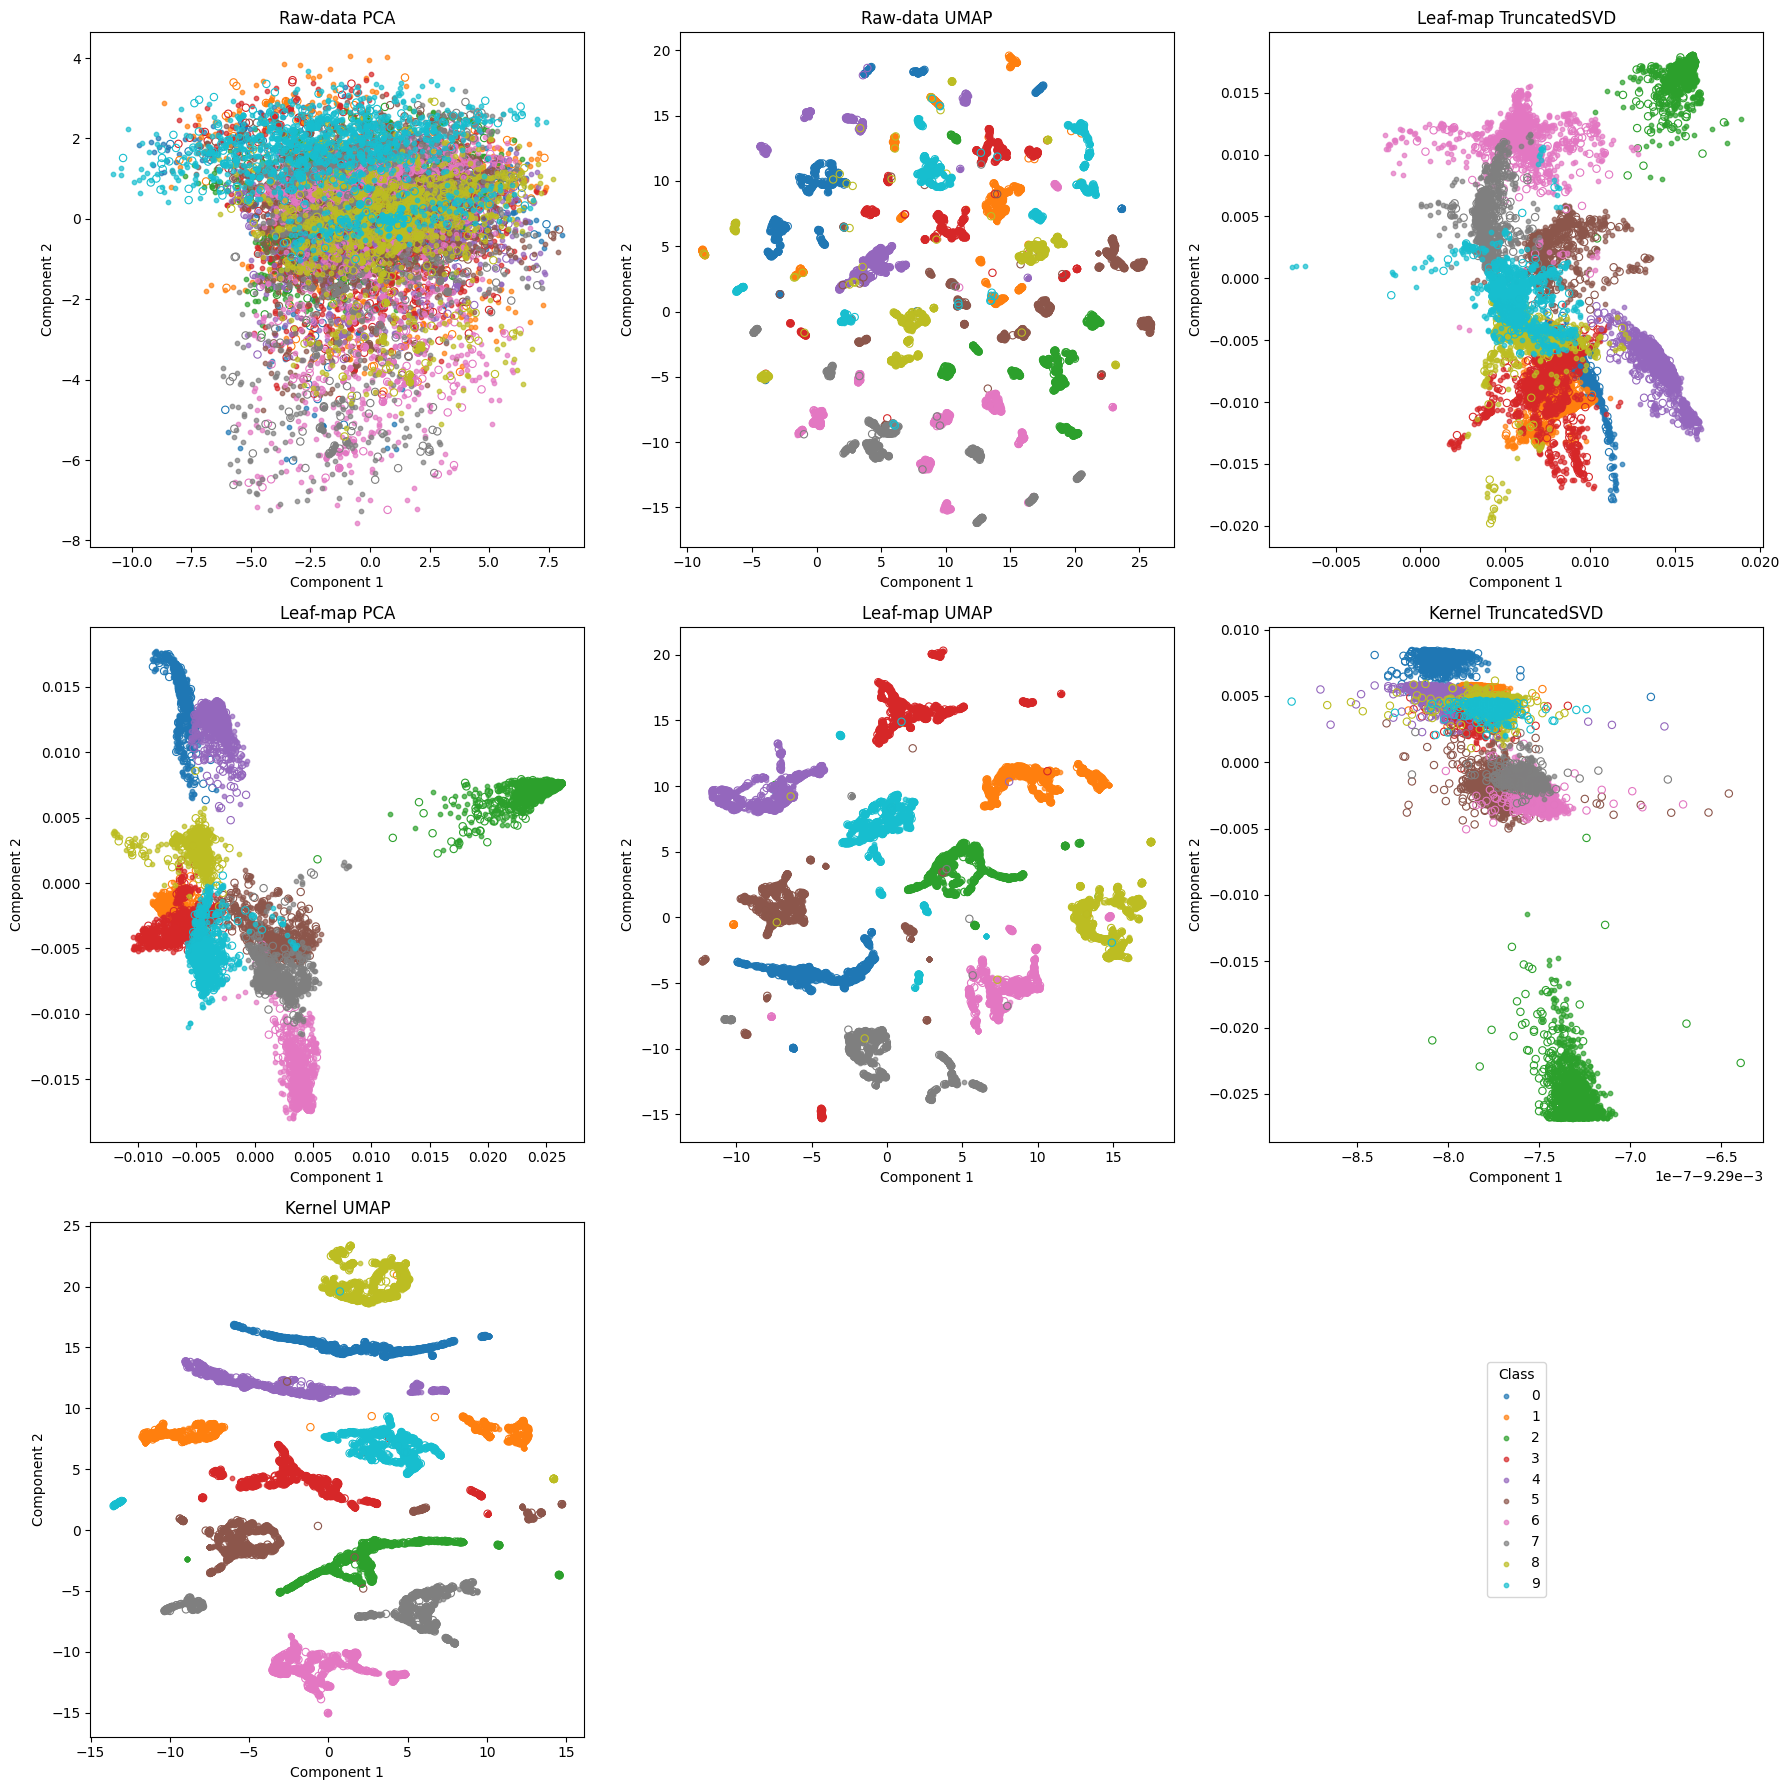

In [ ]:

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
classes = np.unique(y_train)
cmap = plt.get_cmap("tab10")

plots = [
    ((x_pca_raw_train, x_pca_raw_test), "Raw-data PCA"),
    ((x_umap_raw_train, x_umap_raw_test), "Raw-data UMAP"),
    ((x_svd_leaf_train, x_svd_leaf_test), "Leaf-map TruncatedSVD"),
    ((x_pca_leaf_train, x_pca_leaf_test), "Leaf-map PCA"),
    ((x_umap_leaf_train, x_umap_leaf_test), "Leaf-map UMAP"),
    ((x_svd_kernel_train, x_svd_kernel_test), "Kernel TruncatedSVD"),
    ((x_umap_kernel_train, x_umap_kernel_test), "Kernel UMAP"),
]

positions = [(0, 0), (0, 1), (0, 2),
             (1, 0), (1, 1), (1, 2),
             (2, 0)]

for ((emb_train, emb_test), title), (r, c) in zip(plots, positions):
    ax = axes[r, c]

    for i, cls in enumerate(classes):
        color = cmap(i % 10)

        mask_tr = (y_train == cls)
        mask_te = (y_test == cls)

        # train points
        ax.scatter(
            emb_train[mask_tr, 0],
            emb_train[mask_tr, 1],
            s=10,
            alpha=0.7,
            color=color,
            label=str(cls),
        )

        # test points: same class color, but outlined
        ax.scatter(
            emb_test[mask_te, 0],
            emb_test[mask_te, 1],
            s=28,
            facecolors="none",
            edgecolors=[color],
            linewidths=0.8,
        )

    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# Put legend and leave one panel empty
axes[2, 1].axis("off")
axes[2, 2].axis("off")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[2, 2].legend(handles, labels, title="Class", loc="center")

plt.tight_layout()
plt.show()

In [ ]:
w = fk._adapter.get_tree_weights(x_train)
print("shape:", w.shape)
print("sum:", w.sum())
print("min:", w.min())
print("max:", w.max())
print("ratio max/min:", w.max() / max(w.min(), 1e-12))
print("top 20 weights:", np.sort(w)[-20:])

ValueError: Tree weights are not defined for RandomForest / ExtraTrees.